## Unsupervised Learning

### Clustering - Kmeans, Hierarchical and DBscan

#### Alka Pandey

## Problem Statement and Objective: Group similar customers 

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import linkage,dendrogram,cut_tree

In [4]:
retail = pd.read_csv("OnlineRetail1.csv",encoding="ISO-8859-1")
retail

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,01-12-2010 08:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,01-12-2010 08:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,09-12-2011 12:50,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,09-12-2011 12:50,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,09-12-2011 12:50,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,09-12-2011 12:50,4.15,12680.0,France


In [5]:
retail.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [6]:
retail.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [7]:
retail_df = retail.dropna()
retail_df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,01-12-2010 08:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,01-12-2010 08:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,09-12-2011 12:50,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,09-12-2011 12:50,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,09-12-2011 12:50,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,09-12-2011 12:50,4.15,12680.0,France


In [8]:
# Calculate the amount spent for a product which is unit price multiplies by quantity purchased
retail_df["amount"] = retail_df["Quantity"]*retail_df["UnitPrice"]
retail_df

C:\Users\alkap\AppData\Local\Temp\ipykernel_35388\2554512076.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  retail_df["amount"] = retail_df["Quantity"]*retail_df["UnitPrice"]


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,amount
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,01-12-2010 08:26,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,01-12-2010 08:26,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,01-12-2010 08:26,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,01-12-2010 08:26,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,01-12-2010 08:26,3.39,17850.0,United Kingdom,20.34
...,...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,09-12-2011 12:50,0.85,12680.0,France,10.20
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,09-12-2011 12:50,2.10,12680.0,France,12.60
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,09-12-2011 12:50,4.15,12680.0,France,16.60
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,09-12-2011 12:50,4.15,12680.0,France,16.60


In [9]:
# For clustering we need the data at a Customer ID level, hence grouping it to identify customer behavior

grouped_df = retail_df.groupby("CustomerID")["amount"].sum().reset_index()
grouped_df

,CustomerID,amount
0,12346.0,0.00
1,12347.0,4310.00
2,12348.0,1797.24
3,12349.0,1757.55
4,12350.0,334.40
...,...,...
4367,18280.0,180.60
4368,18281.0,80.82
4369,18282.0,176.60
4370,18283.0,2094.88


In [10]:
frequency = retail_df.groupby("CustomerID")["InvoiceNo"].count().reset_index()
frequency

,CustomerID,InvoiceNo
0,12346.0,2
1,12347.0,182
2,12348.0,31
3,12349.0,73
4,12350.0,17
...,...,...
4367,18280.0,10
4368,18281.0,7
4369,18282.0,13
4370,18283.0,756


In [12]:
frequency.columns = ["CustomerID","Frequency"]
frequency

,CustomerID,Frequency
0,12346.0,2
1,12347.0,182
2,12348.0,31
3,12349.0,73
4,12350.0,17
...,...,...
4367,18280.0,10
4368,18281.0,7
4369,18282.0,13
4370,18283.0,756


In [13]:
grouped_df2 = pd.merge(grouped_df,frequency,on="CustomerID")
grouped_df2

,CustomerID,amount,Frequency
0,12346.0,0.00,2
1,12347.0,4310.00,182
2,12348.0,1797.24,31
3,12349.0,1757.55,73
4,12350.0,334.40,17
...,...,...,...
4367,18280.0,180.60,10
4368,18281.0,80.82,7
4369,18282.0,176.60,13
4370,18283.0,2094.88,756


In [14]:
grouped_df2.columns = ["CustomerID","Amount","Frequency"]
grouped_df2

,CustomerID,Amount,Frequency
0,12346.0,0.00,2
1,12347.0,4310.00,182
2,12348.0,1797.24,31
3,12349.0,1757.55,73
4,12350.0,334.40,17
...,...,...,...
4367,18280.0,180.60,10
4368,18281.0,80.82,7
4369,18282.0,176.60,13
4370,18283.0,2094.88,756


### Outlier identification and treatment

In [22]:
Q1 = grouped_df2["Amount"].quantile(0.03)
Q3 = grouped_df2["Amount"].quantile(0.98)
IQR = Q3-Q1

grouped_df3 = grouped_df2[(grouped_df2["Amount"]>=Q1-1.5*IQR) & (grouped_df2["Amount"]<=Q3+1.5*IQR)]
grouped_df3

,CustomerID,Amount,Frequency
0,12346.0,0.00,2
1,12347.0,4310.00,182
2,12348.0,1797.24,31
3,12349.0,1757.55,73
4,12350.0,334.40,17
...,...,...,...
4367,18280.0,180.60,10
4368,18281.0,80.82,7
4369,18282.0,176.60,13
4370,18283.0,2094.88,756


<Axes: ylabel='Amount'>

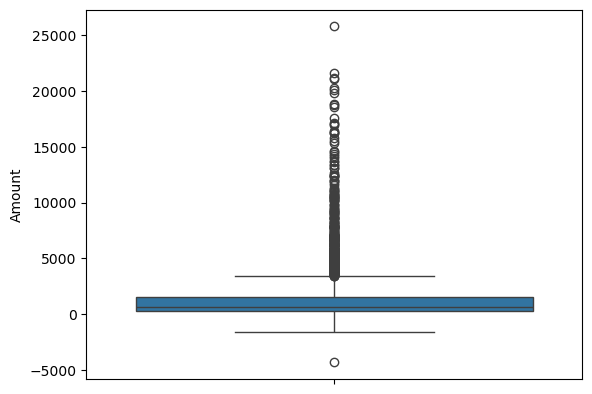

In [23]:
sns.boxplot(grouped_df3["Amount"])

In [24]:
# outlier detection for frequency:

Q1 = grouped_df3["Frequency"].quantile(0.03)
Q3 = grouped_df3["Frequency"].quantile(0.98)
IQR = Q3-Q1

grouped_df3 = grouped_df3[(grouped_df3["Frequency"]>=Q1-1.5*IQR) & (grouped_df3["Frequency"]<=Q3+1.5*IQR)]
grouped_df3

,CustomerID,Amount,Frequency
0,12346.0,0.00,2
1,12347.0,4310.00,182
2,12348.0,1797.24,31
3,12349.0,1757.55,73
4,12350.0,334.40,17
...,...,...,...
4367,18280.0,180.60,10
4368,18281.0,80.82,7
4369,18282.0,176.60,13
4370,18283.0,2094.88,756


In [25]:
rf_df = grouped_df3[["Amount","Frequency"]]

## Scaling the data

In [26]:
scaler = StandardScaler()
rf_df_scaled = scaler.fit_transform(rf_df)
rf_df_scaled

array([[-0.63636011, -0.70552462],
       [ 1.35418864,  0.89427551],
       [ 0.19368486, -0.44777905],
       ...,
       [-0.55479842, -0.60775906],
       [ 0.33114819,  5.99586037],
       [ 0.2121771 , -0.10115568]], shape=(4331, 2))

In [27]:
rf_df_scaled = pd.DataFrame(rf_df_scaled)
rf_df_scaled

,0,1
0,-0.636360,-0.705525
1,1.354189,0.894276
2,0.193685,-0.447779
3,0.175354,-0.074492
4,-0.481919,-0.572208
...,...,...
4326,-0.552951,-0.634422
4327,-0.599034,-0.661086
4328,-0.554798,-0.607759
4329,0.331148,5.995860


In [28]:
rf_df_scaled.columns = ["Amount","Frequency"]
rf_df_scaled

,Amount,Frequency
0,-0.636360,-0.705525
1,1.354189,0.894276
2,0.193685,-0.447779
3,0.175354,-0.074492
4,-0.481919,-0.572208
...,...,...
4326,-0.552951,-0.634422
4327,-0.599034,-0.661086
4328,-0.554798,-0.607759
4329,0.331148,5.995860


### Applying K Means:

In [29]:
kmeans = KMeans(n_clusters= 5)
kmeans.fit(rf_df_scaled)

KMeans(n_clusters=5)

In [30]:
kmeans.labels_

array([0, 2, 0, ..., 0, 4, 3], shape=(4331,), dtype=int32)

In [32]:
grouped_df3["Cluster_KM"] = kmeans.labels_
grouped_df3

C:\Users\alkap\AppData\Local\Temp\ipykernel_35388\3402434281.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  grouped_df3["Cluster_KM"] = kmeans.labels_


,CustomerID,Amount,Frequency,Cluster_KM
0,12346.0,0.00,2,0
1,12347.0,4310.00,182,2
2,12348.0,1797.24,31,0
3,12349.0,1757.55,73,3
4,12350.0,334.40,17,0
...,...,...,...,...
4367,18280.0,180.60,10,0
4368,18281.0,80.82,7,0
4369,18282.0,176.60,13,0
4370,18283.0,2094.88,756,4


## Identifying the right value of "K"

In [33]:
ssd = []
n_clust = [2,3,4,5,6,7,8,9]

for num_clusters in n_clust:
    kmeans = KMeans(n_clusters=num_clusters)
    kmeans.fit(rf_df_scaled)
    ssd.append(kmeans.inertia_)

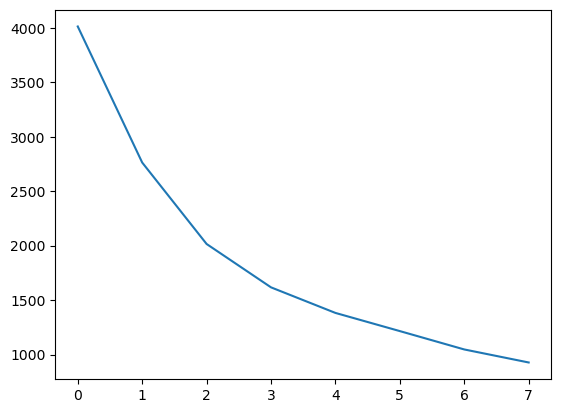

In [34]:
plt.plot(ssd)

In [35]:
# via silhouette score


n_clust = [2,3,4,5,6,7,8,9]

for num_clusters in n_clust:
    kmeans = KMeans(n_clusters=num_clusters)
    kmeans.fit(rf_df_scaled)
    cluster_labels = kmeans.labels_
    silhouette_s = silhouette_score(rf_df_scaled,cluster_labels)
    print("For cluster {} the Silhouette score is {}".format(num_clusters,silhouette_s))

For cluster 2 the Silhouette score is 0.7428115924538498
For cluster 3 the Silhouette score is 0.639500521680747
For cluster 4 the Silhouette score is 0.6153561165138258
For cluster 5 the Silhouette score is 0.5629779302458654
For cluster 6 the Silhouette score is 0.5576403565415566
For cluster 7 the Silhouette score is 0.49362561861986054
For cluster 8 the Silhouette score is 0.505560155438721
For cluster 9 the Silhouette score is 0.5023318162289789


In [36]:
## Now with 3 clusters fit a final k means:

kmeans = KMeans(n_clusters=3)
kmeans.fit(rf_df_scaled)

KMeans(n_clusters=3)

In [37]:
grouped_df3["Cluster_KM"] = kmeans.labels_
grouped_df3

C:\Users\alkap\AppData\Local\Temp\ipykernel_35388\3402434281.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  grouped_df3["Cluster_KM"] = kmeans.labels_


,CustomerID,Amount,Frequency,Cluster_KM
0,12346.0,0.00,2,0
1,12347.0,4310.00,182,1
2,12348.0,1797.24,31,0
3,12349.0,1757.55,73,0
4,12350.0,334.40,17,0
...,...,...,...,...
4367,18280.0,180.60,10,0
4368,18281.0,80.82,7,0
4369,18282.0,176.60,13,0
4370,18283.0,2094.88,756,2


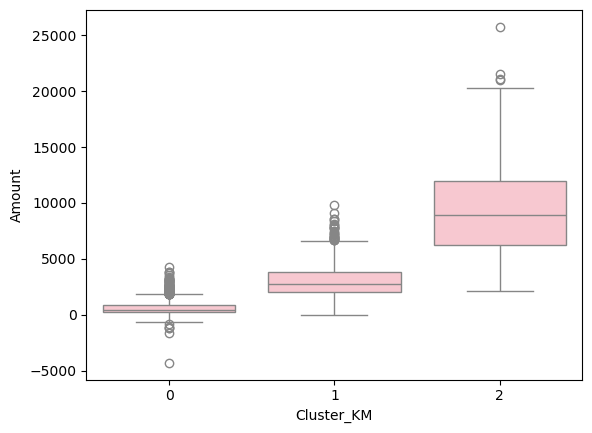

In [38]:
sns.boxplot(x="Cluster_KM",y="Amount",data= grouped_df3,color="pink")
plt.show()

# Hierarchical Clustering

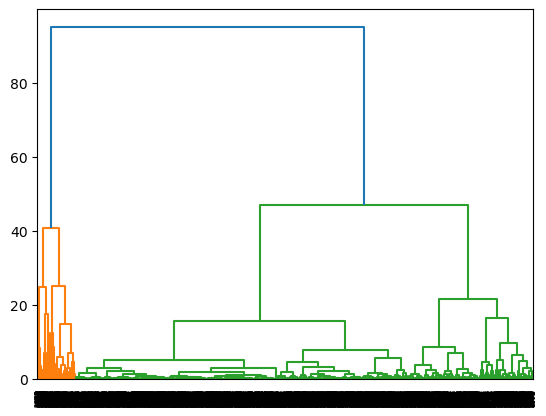

In [42]:
mergings = linkage(rf_df_scaled,method = "ward",metric="euclidean")
dendrogram(mergings)
plt.show()

In [43]:
cluster_labels = cut_tree(mergings,n_clusters=4).reshape(-1,)
cluster_labels

array([0, 1, 0, ..., 0, 3, 0], shape=(4331,))

In [44]:
grouped_df3["Cluster_HC"] = cluster_labels

C:\Users\alkap\AppData\Local\Temp\ipykernel_35388\712119111.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  grouped_df3["Cluster_HC"] = cluster_labels


In [45]:
grouped_df3

,CustomerID,Amount,Frequency,Cluster_KM,Cluster_HC
0,12346.0,0.00,2,0,0
1,12347.0,4310.00,182,1,1
2,12348.0,1797.24,31,0,0
3,12349.0,1757.55,73,0,1
4,12350.0,334.40,17,0,0
...,...,...,...,...,...
4367,18280.0,180.60,10,0,0
4368,18281.0,80.82,7,0,0
4369,18282.0,176.60,13,0,0
4370,18283.0,2094.88,756,2,3


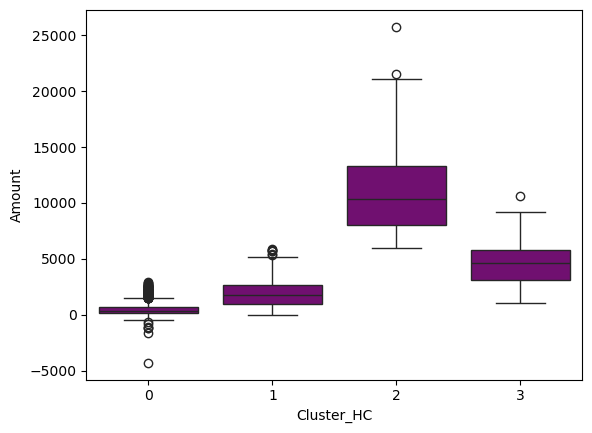

In [46]:
sns.boxplot(x="Cluster_HC",y="Amount",data= grouped_df3,color="purple")
plt.show()

# DB Scan algorithm

In [50]:
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming rf_df_scaled is a NumPy array or a pandas DataFrame of scaled features

# Step 1: Initialize DBSCAN
# eps = neighborhood radius, min_samples = minimum points to form a dense region
dbscan = DBSCAN(eps=0.5, min_samples=5)

# Step 2: Fit DBSCAN
dbscan.fit(rf_df_scaled)

# Step 3: Extract cluster labels
labels = dbscan.labels_

# Step 4: Add labels back to your DataFrame (if rf_df_scaled is a DataFrame)
import pandas as pd
rf_df_scaled = pd.DataFrame(rf_df_scaled)  # if not already a DataFrame
rf_df_scaled['Cluster'] = labels



In [51]:
grouped_df3["Cluster_Dbscan"] = labels
grouped_df3

C:\Users\alkap\AppData\Local\Temp\ipykernel_35388\2465712423.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  grouped_df3["Cluster_Dbscan"] = labels


,CustomerID,Amount,Frequency,Cluster_KM,Cluster_HC,Cluster_Dbscan
0,12346.0,0.00,2,0,0,0
1,12347.0,4310.00,182,1,1,0
2,12348.0,1797.24,31,0,0,0
3,12349.0,1757.55,73,0,1,0
4,12350.0,334.40,17,0,0,0
...,...,...,...,...,...,...
4367,18280.0,180.60,10,0,0,0
4368,18281.0,80.82,7,0,0,0
4369,18282.0,176.60,13,0,0,0
4370,18283.0,2094.88,756,2,3,-1


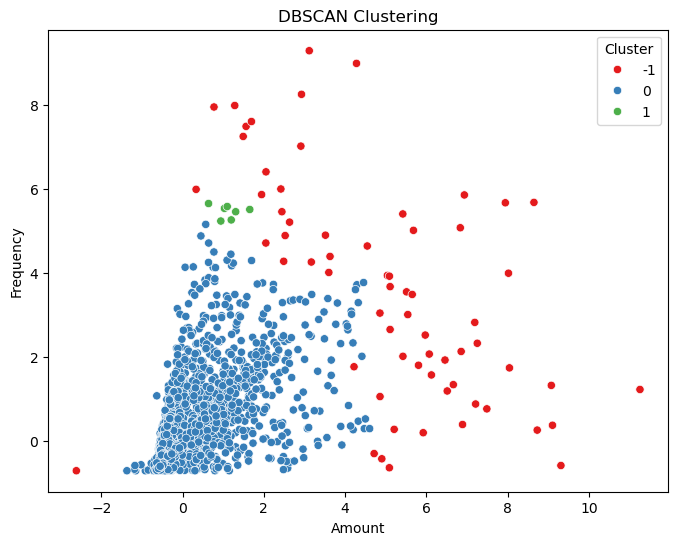

In [52]:
# Optional : Generally do not visually if more than 2D


# Step 5: Visualize clusters (for 2D data)
plt.figure(figsize=(8,6))
sns.scatterplot(
    x=rf_df_scaled.iloc[:,0], 
    y=rf_df_scaled.iloc[:,1], 
    hue=rf_df_scaled['Cluster'], 
    palette='Set1'
)
plt.title("DBSCAN Clustering")
plt.show()
